# Polyagamma GP Negative Binomial Demo On Chicago Taxi Pickup Counts

This notebook builds a spatial count benchmark from the Chicago taxi
trip table the user provided.

To keep the problem both large and numerically reasonable, the default
setup is:

- raw data: January 2024 trips with non-null pickup centroids
- predictor: spatial cell centroid `(pickup_lon, pickup_lat)`
- response: number of trips in each `(day, spatial cell)` bin

So the GP still sees a 2D spatial domain, but the response is a
collection of repeated daily count observations over that spatial grid.

Caveat: the pickup coordinates are privacy-preserving centroids rather
than exact GPS points, so this is denser than hour-of-day but still not
fully continuous ground-truth location data.


In [ ]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

DATA_DIR = Path("data")

from polyagamma_classification.pg_classifier import PolyagammaGPNegativeBinomialRegressor

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(suppress=True, precision=4)


## Download And Cache A Trimmed Chicago Taxi Slice

The full Socrata table has more than 14 million rows, so the notebook
caches a smaller query containing only the columns we need for January
2024 pickup-centroid trips.


In [ ]:
DATASET_ID = "ajtu-isnz"
SLICE_START = "2024-01-01T00:00:00"
SLICE_END = "2024-02-01T00:00:00"

CACHE_PATH = DATA_DIR / "taxi_pickups_2024_01_centroids.csv"
CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

def build_chicago_query_url():
    d = chr(36)
    base = f"https://data.cityofchicago.org/resource/{DATASET_ID}.csv?"
    where = (
        "pickup_centroid_latitude IS NOT NULL AND "
        "pickup_centroid_longitude IS NOT NULL AND "
        f"trip_start_timestamp >= '{SLICE_START}' AND "
        f"trip_start_timestamp < '{SLICE_END}'"
    )
    where_enc = where.replace(" ", "%20").replace("'", "%27")
    select = "trip_start_timestamp,pickup_centroid_latitude,pickup_centroid_longitude"
    return base + f"{d}select=" + select + f"&{d}where=" + where_enc + f"&{d}limit=1000000"


QUERY_URL = build_chicago_query_url()

if not CACHE_PATH.exists():
    print("Downloading trimmed Chicago taxi slice ...")
    taxi_raw = pd.read_csv(QUERY_URL)
    taxi_raw.to_csv(CACHE_PATH, index=False)

print(f"Cache path: {CACHE_PATH}")
print(f"Size: {CACHE_PATH.stat().st_size / 1e6:.2f} MB")


## Load Trips And Aggregate To Daily Spatial Counts

The raw query still has one row per trip. We place each pickup centroid
into a fine spatial grid, then count trips separately for each day and
grid cell.

By default the notebook trains on all `(day, cell)` rows.


In [12]:
GRID_SIZE = 32
DISPLAY_GRID_SIZE = 64

use_all_data_for_training = True
holdout_stride = 5

df = pd.read_csv(CACHE_PATH)
df["trip_start_timestamp"] = pd.to_datetime(df["trip_start_timestamp"])
df["day"] = df["trip_start_timestamp"].dt.floor("D")

lon_min = float(df["pickup_centroid_longitude"].min())
lon_max = float(df["pickup_centroid_longitude"].max())
lat_min = float(df["pickup_centroid_latitude"].min())
lat_max = float(df["pickup_centroid_latitude"].max())

lon_edges = np.linspace(lon_min, lon_max, GRID_SIZE + 1)
lat_edges = np.linspace(lat_min, lat_max, GRID_SIZE + 1)
lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])
lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])

lon_idx = np.searchsorted(lon_edges, df["pickup_centroid_longitude"].to_numpy(), side="right") - 1
lat_idx = np.searchsorted(lat_edges, df["pickup_centroid_latitude"].to_numpy(), side="right") - 1
lon_idx = np.clip(lon_idx, 0, GRID_SIZE - 1)
lat_idx = np.clip(lat_idx, 0, GRID_SIZE - 1)

grouped = df[["day"]].copy()
grouped["lon_idx"] = lon_idx
grouped["lat_idx"] = lat_idx
grouped["count"] = 1
grouped = grouped.groupby(["day", "lon_idx", "lat_idx"], as_index=False)["count"].sum()

all_days = np.sort(df["day"].unique())
full_index = pd.MultiIndex.from_product(
    [all_days, np.arange(GRID_SIZE), np.arange(GRID_SIZE)],
    names=["day", "lon_idx", "lat_idx"],
).to_frame(index=False)
cell_day = full_index.merge(grouped, on=["day", "lon_idx", "lat_idx"], how="left")
cell_day["count"] = cell_day["count"].fillna(0.0)

X_raw_np = np.column_stack(
    [
        lon_centers[cell_day["lon_idx"].to_numpy(dtype=int)],
        lat_centers[cell_day["lat_idx"].to_numpy(dtype=int)],
    ]
)
y_all_np = cell_day["count"].to_numpy(dtype=np.float64)

x_min = X_raw_np.min(axis=0)
x_max = X_raw_np.max(axis=0)
x_span = np.where(x_max > x_min, x_max - x_min, 1.0)
X_all_np = 2.0 * (X_raw_np - x_min) / x_span - 1.0

if use_all_data_for_training:
    mask_train = np.ones(X_all_np.shape[0], dtype=bool)
    mask_test = np.zeros(X_all_np.shape[0], dtype=bool)
    X_train_np = X_all_np
    y_train_np = y_all_np
    X_test_np = np.empty((0, 2), dtype=np.float64)
    y_test_np = np.empty((0,), dtype=np.float64)
else:
    mask_test = (np.arange(X_all_np.shape[0]) % holdout_stride) == 0
    mask_train = np.logical_not(mask_test)
    X_train_np = X_all_np[mask_train]
    y_train_np = y_all_np[mask_train]
    X_test_np = X_all_np[mask_test]
    y_test_np = y_all_np[mask_test]

display_lon = np.linspace(lon_min, lon_max, DISPLAY_GRID_SIZE)
display_lat = np.linspace(lat_min, lat_max, DISPLAY_GRID_SIZE)
dlon, dlat = np.meshgrid(display_lon, display_lat, indexing="ij")
X_display_raw = np.column_stack([dlon.reshape(-1), dlat.reshape(-1)])
X_display_np = 2.0 * (X_display_raw - x_min) / x_span - 1.0

monthly_counts_grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float64)
np.add.at(monthly_counts_grid, (cell_day["lon_idx"], cell_day["lat_idx"]), cell_day["count"])
mean_daily_counts_grid = monthly_counts_grid / float(all_days.size)

daily_totals = cell_day.groupby("day", as_index=False)["count"].sum()

print(f"Trips in cached slice: {df.shape[0]}")
print(f"Unique pickup centroids in raw data: {df[['pickup_centroid_latitude', 'pickup_centroid_longitude']].drop_duplicates().shape[0]}")
print(f"Days: {all_days.size}")
print(f"(day, cell) rows: {X_all_np.shape[0]}")
print(f"Mean count per (day, cell): {y_all_np.mean():.4f}")
print(f"Max count per (day, cell): {y_all_np.max():.0f}")
print(f"Fraction of zero-count (day, cell) rows: {np.mean(y_all_np == 0):.4f}")
print(f"Normalized predictor bounds: min={X_all_np.min(axis=0)}, max={X_all_np.max(axis=0)}")
if use_all_data_for_training:
    print("Training mode: all rows used for fitting")
else:
    print(f"Training mode: stride holdout with every {holdout_stride}th row in test")


Trips in cached slice: 414217
Unique pickup centroids in raw data: 275
Days: 31
(day, cell) rows: 31744
Mean count per (day, cell): 13.0487
Max count per (day, cell): 4986
Fraction of zero-count (day, cell) rows: 0.8938
Normalized predictor bounds: min=[-1. -1.], max=[1. 1.]
Training mode: all rows used for fitting


## Visualize The Raw Trips And The Aggregated Spatial Counts

This section shows:

- daily total trips through the month
- a sample of raw pickup-centroid locations
- the busiest day as a spatial count map


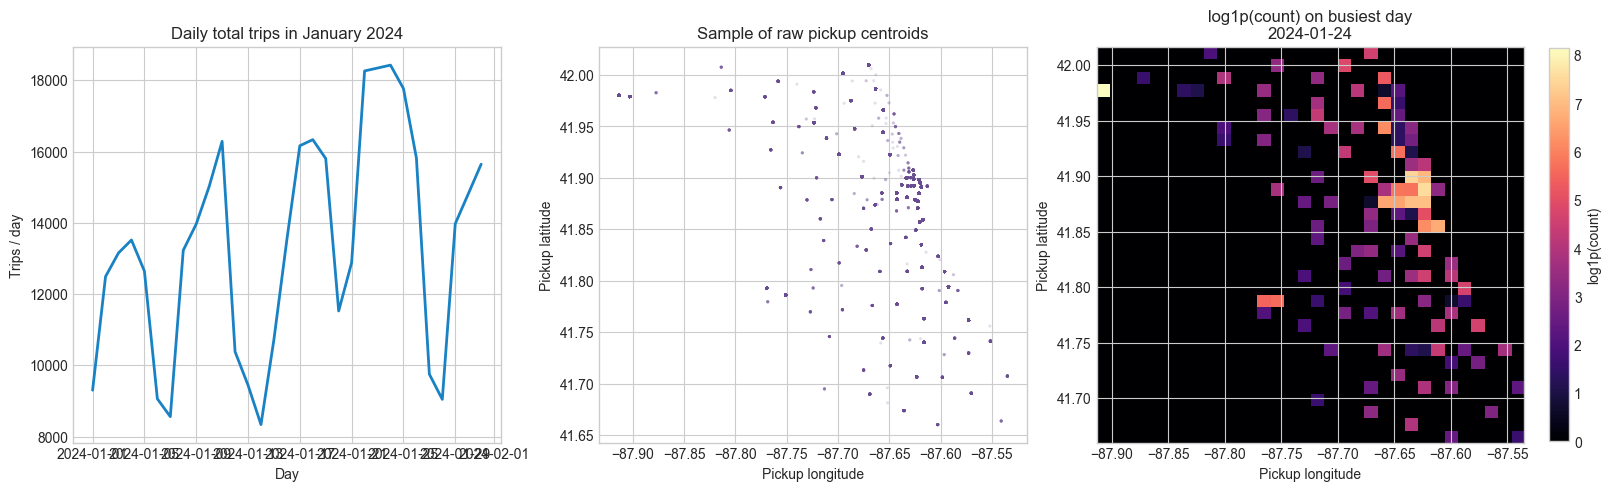

In [13]:
rng = np.random.default_rng(0)
sample_size = min(25_000, df.shape[0])
sample_idx = np.sort(rng.choice(df.shape[0], size=sample_size, replace=False))
df_sample = df.iloc[sample_idx]

busiest_day = daily_totals.loc[daily_totals["count"].idxmax(), "day"]
busiest_rows = cell_day[cell_day["day"] == busiest_day]
busiest_grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float64)
busiest_grid[busiest_rows["lon_idx"], busiest_rows["lat_idx"]] = busiest_rows["count"].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
extent = [lon_min, lon_max, lat_min, lat_max]

axes[0].plot(daily_totals["day"], daily_totals["count"], color="#1982c4", linewidth=2)
axes[0].set_title("Daily total trips in January 2024")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Trips / day")

axes[1].scatter(
    df_sample["pickup_centroid_longitude"],
    df_sample["pickup_centroid_latitude"],
    s=5,
    alpha=0.18,
    color="#6a4c93",
    edgecolors="none",
)
axes[1].set_title("Sample of raw pickup centroids")
axes[1].set_xlabel("Pickup longitude")
axes[1].set_ylabel("Pickup latitude")

im = axes[2].imshow(
    np.log1p(busiest_grid).T,
    origin="lower",
    extent=extent,
    cmap="magma",
    aspect="auto",
)
axes[2].set_title(f"log1p(count) on busiest day\n{pd.Timestamp(busiest_day).date()}")
axes[2].set_xlabel("Pickup longitude")
axes[2].set_ylabel("Pickup latitude")
fig.colorbar(im, ax=axes[2], fraction=0.046, label="log1p(count)")


## Fit `PolyagammaGPNegativeBinomialRegressor` With Learned `r`

The GP only sees spatial coordinates. Repeating the same spatial inputs
across days means the model learns a shared spatial intensity surface
while the day-to-day variability remains in the count noise.


In [14]:
reg = PolyagammaGPNegativeBinomialRegressor(
    total_count=5.0,
    learn_total_count=True,
    total_count_lr=0.05,
    total_count_update_frequency=1,
    total_count_quadrature_nodes=16,
    lengthscale_init=0.18,
    variance_init=1.0,
    max_iter=200,
    e_step_iters=1,
    final_e_step_iters=2,
    rho0=1.0,
    gamma=1e-3,
    lr=0.04,
    n_e_probes=1,
    n_m_probes=1,
    cg_tol=1e-5,
    nufft_eps=1e-4,
    spectral_eps=1e-4,
    trunc_eps=1e-4,
    prediction_batch_size=512,
    predictive_variance_method="chebyshev",
    predictive_variance_chebyshev_nodes=7,
    use_exact_weighted_toeplitz_operator=True,
    random_state=0,
    device="cpu",
    store_history=True,
    verbose=1,
)

t_fit = time.time()
reg.fit(X_train_np, y_train_np)
fit_time = time.time() - t_fit

pred_train = reg.predict_mean_count(X_train_np)
if X_test_np.shape[0] > 0:
    pred_test = reg.predict_mean_count(X_test_np)
else:
    pred_test = None

print(f"Fit time: {fit_time:.2f} s")
print(f"Learned lengthscale: {reg.lengthscale_:.4f}")
print(f"Learned variance: {reg.variance_:.4f}")
print(f"Learned total_count r: {reg.total_count_:.4f}")
print(f"Training MAE: {np.mean(np.abs(pred_train - y_train_np)):.5f}")
print(f"Mean predicted training count: {pred_train.mean():.5f}")
print(f"Mean observed training count: {y_train_np.mean():.5f}")
if pred_test is not None:
    print(f"Test MAE: {np.mean(np.abs(pred_test - y_test_np)):.5f}")
else:
    print("Held-out test split: disabled")


outer   0 lengthscale=0.17294 variance=1.04081 grad=(-1.852e+05, +2.822e+03) count_mae=14.4353
outer   1 lengthscale=0.16616 variance=1.08334 grad=(-2.010e+05, +2.933e+03) count_mae=14.1421
outer   2 lengthscale=0.15963 variance=1.12767 grad=(-2.094e+05, +2.900e+03) count_mae=13.9197
outer   3 lengthscale=0.15338 variance=1.17388 grad=(-2.056e+05, +2.823e+03) count_mae=13.7178
outer   4 lengthscale=0.14737 variance=1.22206 grad=(-2.241e+05, +2.802e+03) count_mae=13.5317
outer   5 lengthscale=0.14157 variance=1.27237 grad=(-2.475e+05, +2.809e+03) count_mae=13.3561
outer   6 lengthscale=0.13599 variance=1.32494 grad=(-2.585e+05, +2.817e+03) count_mae=13.1963
outer   7 lengthscale=0.13062 variance=1.37991 grad=(-2.823e+05, +2.827e+03) count_mae=13.0370
outer   8 lengthscale=0.12543 variance=1.43744 grad=(-3.026e+05, +2.837e+03) count_mae=12.8726
outer   9 lengthscale=0.12043 variance=1.49769 grad=(-3.346e+05, +2.835e+03) count_mae=12.6996
outer  10 lengthscale=0.11560 variance=1.56079 gra

## Compare The Empirical Mean Daily Surface With The GP Fit

We compare the empirical average daily count per spatial cell against
the GP's predicted mean count surface.


In [15]:
unique_cell_raw = np.column_stack(
    [
        np.repeat(lon_centers, GRID_SIZE),
        np.tile(lat_centers, GRID_SIZE),
    ]
)
unique_cell_np = 2.0 * (unique_cell_raw - x_min) / x_span - 1.0
mean_count_cells = reg.predict_mean_count(unique_cell_np).reshape(GRID_SIZE, GRID_SIZE)

latent_display = reg.decision_function(X_display_np)
var_display = reg.predictive_variance(X_display_np)
mean_count_display = reg.total_count_ * np.exp(latent_display + 0.5 * var_display)

latent_display_img = latent_display.reshape(DISPLAY_GRID_SIZE, DISPLAY_GRID_SIZE)
var_display_img = var_display.reshape(DISPLAY_GRID_SIZE, DISPLAY_GRID_SIZE)
mean_count_display_img = mean_count_display.reshape(DISPLAY_GRID_SIZE, DISPLAY_GRID_SIZE)

history = reg.history_
iters = np.array([row["iter"] for row in history], dtype=float)
lengthscales = np.array([row["lengthscale"] for row in history], dtype=float)
variances = np.array([row["variance"] for row in history], dtype=float)
total_counts = np.array([row["total_count"] for row in history], dtype=float)
count_mae = np.array([row["mean_count_mae"] for row in history], dtype=float)


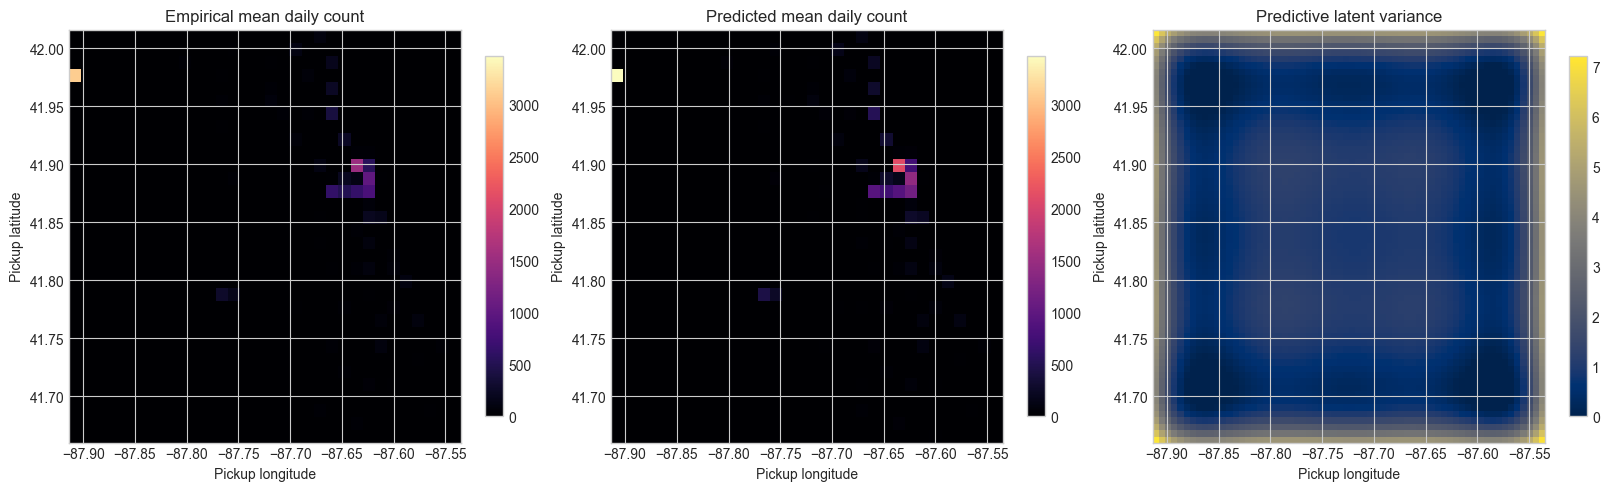

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
extent = [lon_min, lon_max, lat_min, lat_max]

vmax = max(float(np.nanmax(mean_daily_counts_grid)), float(np.nanmax(mean_count_cells)))

im0 = axes[0].imshow(
    mean_daily_counts_grid.T,
    origin="lower",
    extent=extent,
    cmap="magma",
    aspect="auto",
    vmin=0.0,
    vmax=vmax,
)
axes[0].set_title("Empirical mean daily count")
axes[0].set_xlabel("Pickup longitude")
axes[0].set_ylabel("Pickup latitude")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(
    mean_count_cells.T,
    origin="lower",
    extent=extent,
    cmap="magma",
    aspect="auto",
    vmin=0.0,
    vmax=vmax,
)
axes[1].set_title("Predicted mean daily count")
axes[1].set_xlabel("Pickup longitude")
axes[1].set_ylabel("Pickup latitude")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(
    var_display_img.T,
    origin="lower",
    extent=extent,
    cmap="cividis",
    aspect="auto",
)
axes[2].set_title("Predictive latent variance")
axes[2].set_xlabel("Pickup longitude")
axes[2].set_ylabel("Pickup latitude")
fig.colorbar(im2, ax=axes[2], fraction=0.046)


Text(0.5, 0, 'Outer iteration')

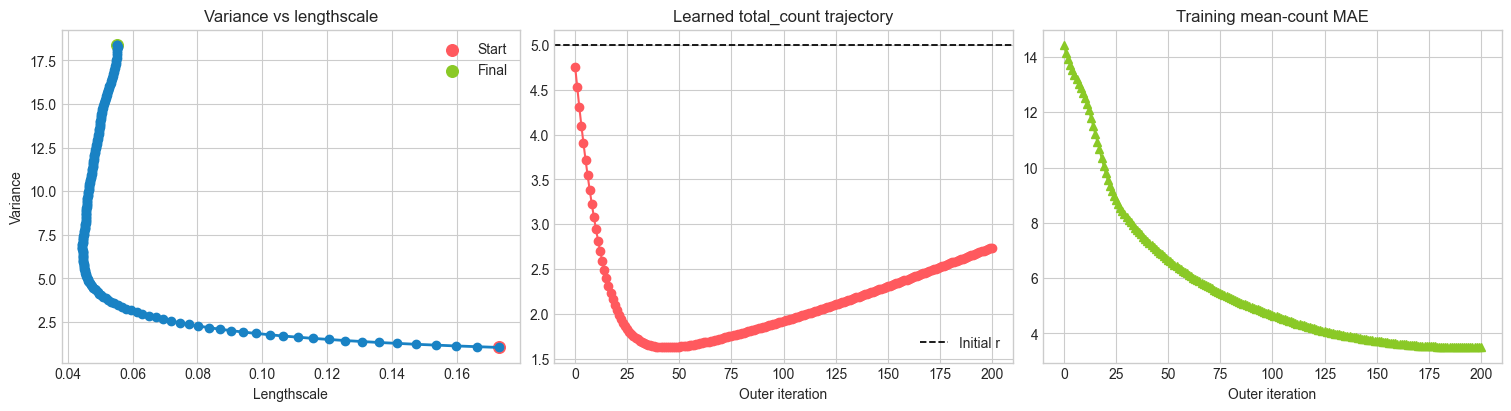

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].plot(lengthscales, variances, color="#1982c4", marker="o", linewidth=2)
axes[0].scatter(lengthscales[0], variances[0], color="#ff595e", s=70, label="Start")
axes[0].scatter(lengthscales[-1], variances[-1], color="#8ac926", s=70, label="Final")
axes[0].set_title("Variance vs lengthscale")
axes[0].set_xlabel("Lengthscale")
axes[0].set_ylabel("Variance")
axes[0].legend(loc="best")

axes[1].plot(iters, total_counts, marker="o", color="#ff595e")
axes[1].axhline(5.0, color="black", linestyle="--", linewidth=1.25, label="Initial r")
axes[1].set_title("Learned total_count trajectory")
axes[1].set_xlabel("Outer iteration")
axes[1].legend(loc="best")

axes[2].plot(iters, count_mae, marker="^", color="#8ac926")
axes[2].set_title("Training mean-count MAE")
axes[2].set_xlabel("Outer iteration")


In [18]:
summary = {
    "n_raw_trips": int(df.shape[0]),
    "n_days": int(all_days.size),
    "n_cell_day_rows": int(X_all_np.shape[0]),
    "used_all_data_for_training": bool(use_all_data_for_training),
    "fit_time_sec": fit_time,
    "lengthscale": float(reg.lengthscale_),
    "variance": float(reg.variance_),
    "total_count": float(reg.total_count_),
    "train_mae": float(np.mean(np.abs(pred_train - y_train_np))),
    "mean_pred_train": float(pred_train.mean()),
    "mean_obs_train": float(y_train_np.mean()),
    "test_mae": None if pred_test is None else float(np.mean(np.abs(pred_test - y_test_np))),
}
summary


{'n_raw_trips': 414217,
 'n_days': 31,
 'n_cell_day_rows': 31744,
 'used_all_data_for_training': True,
 'fit_time_sec': 368.9568700790405,
 'lengthscale': 0.05535880848765373,
 'variance': 18.392236709594727,
 'total_count': 2.7321792078101854,
 'train_mae': 3.4952715575258004,
 'mean_pred_train': 13.626596006692166,
 'mean_obs_train': 13.048670614919354,
 'test_mae': None}